In [1]:
# Import libraries
import numpy as np
import math
import pandas as pd
import os
# Import graphing libraries
import matplotlib.pyplot as plt
import seaborn as sns  # Theme
import pickle
from matplotlib.dates import DayLocator, MonthLocator, DateFormatter

In [2]:
# Folder to place our matplotlib figures in
figures_folder_name = "figures"

In [3]:
# --- Import dataset ---
dataset = pd.read_csv("../data/mag7_stocks.csv")

# --- Dynamically detect common column names regardless of case or exact spelling ---

# Convert all column names to lowercase for flexible matching
dataset.columns = [c.strip().lower() for c in dataset.columns]

# Create a mapping dictionary of possible variants
possible_names = {
    "name": ["name", "ticker", "symbol", "company"],
    "date": ["date", "datetime", "day", "timestamp"],
    "open": ["open", "opening", "open_price"],
    "high": ["high", "highest", "max_price"],
    "low": ["low", "lowest", "min_price"],
    "close": ["close", "adj close", "closing", "price", "closing_price"],
    "volume": ["volume", "vol", "traded_volume"]
}

# Find actual matching column names in dataset
resolved_cols = {}
for key, variants in possible_names.items():
    for v in variants:
        if v in dataset.columns:
            resolved_cols[key] = v
            break
    else:
        resolved_cols[key] = None  # Mark missing if not found

# Check if all required columns are present
missing = [k for k, v in resolved_cols.items() if v is None]
if missing:
    print(f"⚠️ Warning: Missing columns for {missing}. Some metrics may be skipped.")
else:
    print("✅ All required columns found:", resolved_cols)

# Assign resolved column names for the rest of the script
COL_NAME = resolved_cols["name"]
COL_DATE = resolved_cols["date"]
COL_OPEN = resolved_cols["open"]
COL_HIGH = resolved_cols["high"]
COL_LOW = resolved_cols["low"]
COL_CLOSE = resolved_cols["close"]
COL_VOLUME = resolved_cols["volume"]

# Convert date column to datetime
dataset[COL_DATE] = pd.to_datetime(dataset[COL_DATE])

# --- Quick check to verify dataset loaded correctly ---
print(dataset.head(), "\n")
dataset.info()

✅ All required columns found: {'name': 'ticker', 'date': 'date', 'open': 'open', 'high': 'high', 'low': 'low', 'close': 'close', 'volume': 'volume'}
   unnamed: 0       date ticker       open       high        low      close  \
0           0 2019-01-02   AAPL  38.722500  39.712502  38.557499  39.480000   
1           1 2019-01-02   AAPL  38.722500  39.712502  38.557499  39.480000   
2           2 2019-01-03   AAPL  35.994999  36.430000  35.500000  35.547501   
3           3 2019-01-03   AAPL  35.994999  36.430000  35.500000  35.547501   
4           4 2019-01-04   AAPL  36.132500  37.137501  35.950001  37.064999   

      volume  
0  148158800  
1  148158800  
2  365248800  
3  365248800  
4  234428400   

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14112 entries, 0 to 14111
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   unnamed: 0  14112 non-null  int64         
 1   date        14112 non-null 

In [4]:
# Show companies
companies = dataset["ticker"].dropna().unique().tolist()
print(companies)

['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT', 'NVDA', 'TSLA']


In [5]:
# Identify column names from dataset
COL_DATE = "date"
COL_NAME = "ticker"
COL_OPEN = "open"
COL_HIGH = "high"
COL_LOW = "low"
COL_CLOSE = "close"
COL_VOLUME = "volume"

In [6]:
# Theme of graphs
sns.set_theme(context="notebook", style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.frameon": True,
    "legend.framealpha": 1,
})

AAPL: detected 1 runs of 3+ days


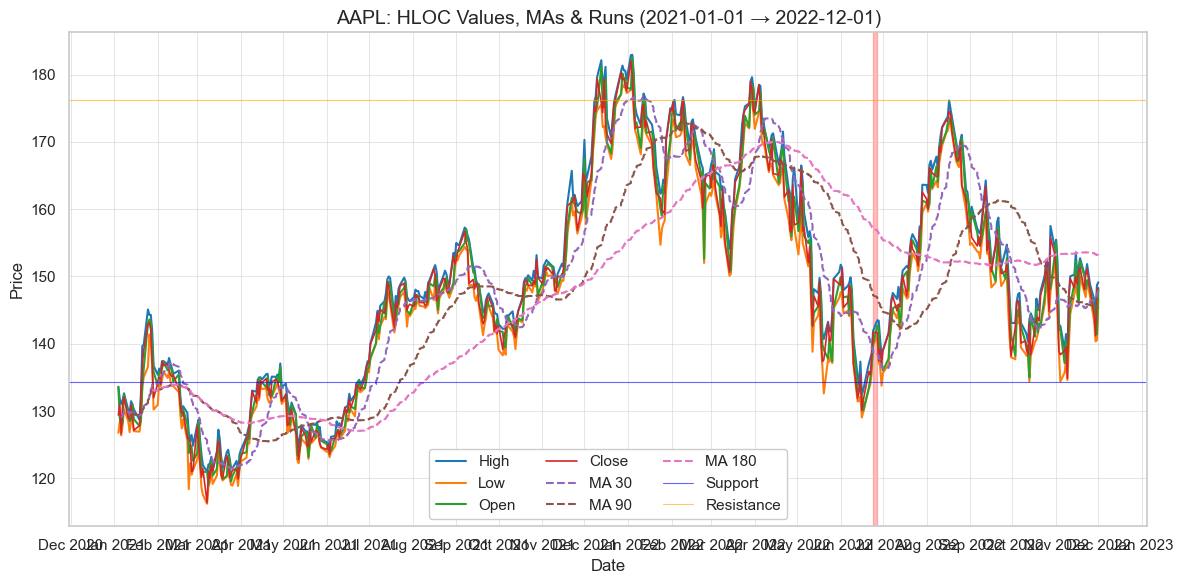

Completed chart for AAPL.

AMZN: detected 0 runs of 3+ days


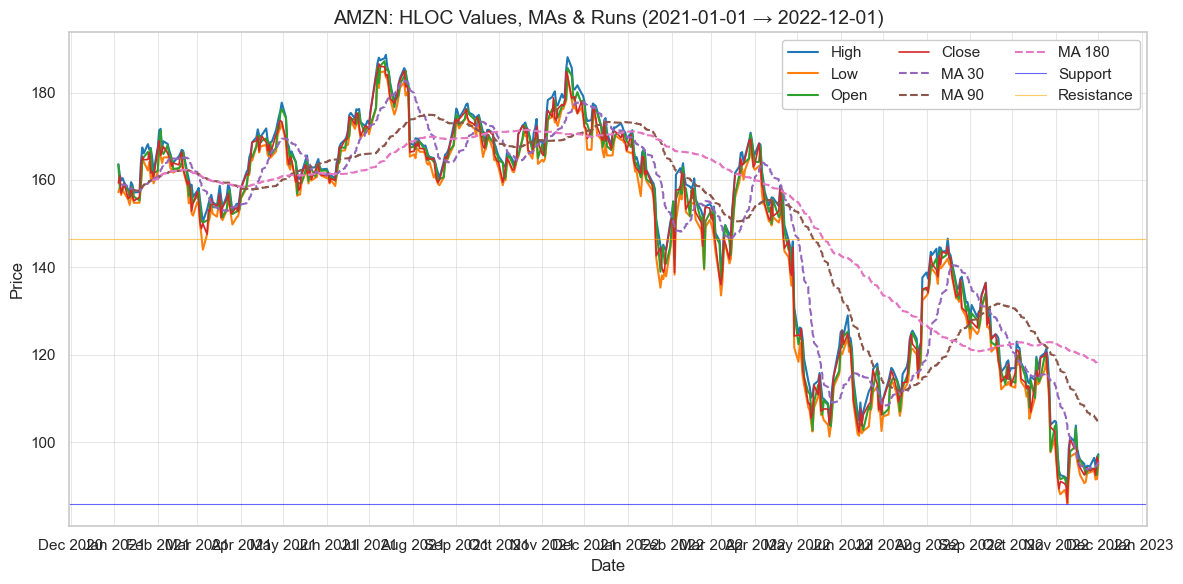

Completed chart for AMZN.

GOOGL: detected 1 runs of 3+ days


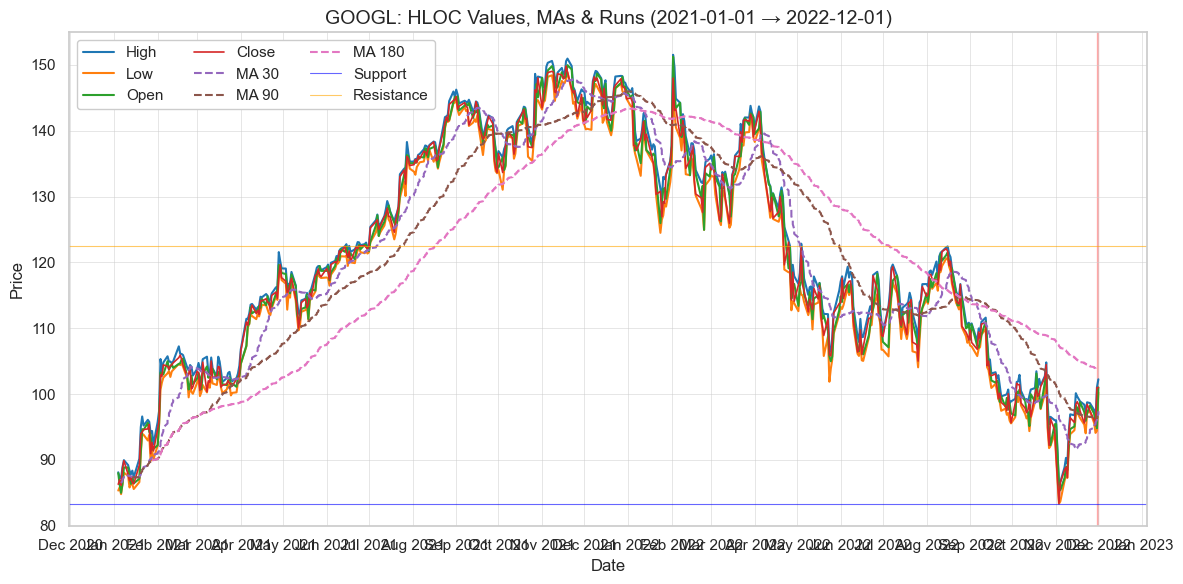

Completed chart for GOOGL.

META: detected 0 runs of 3+ days


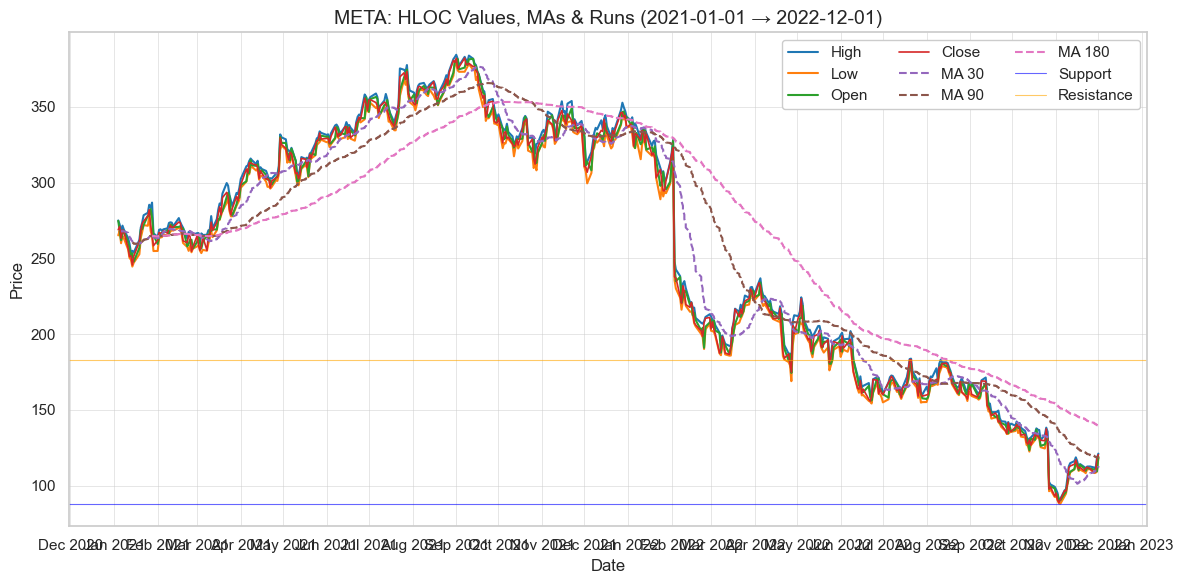

Completed chart for META.

MSFT: detected 1 runs of 3+ days


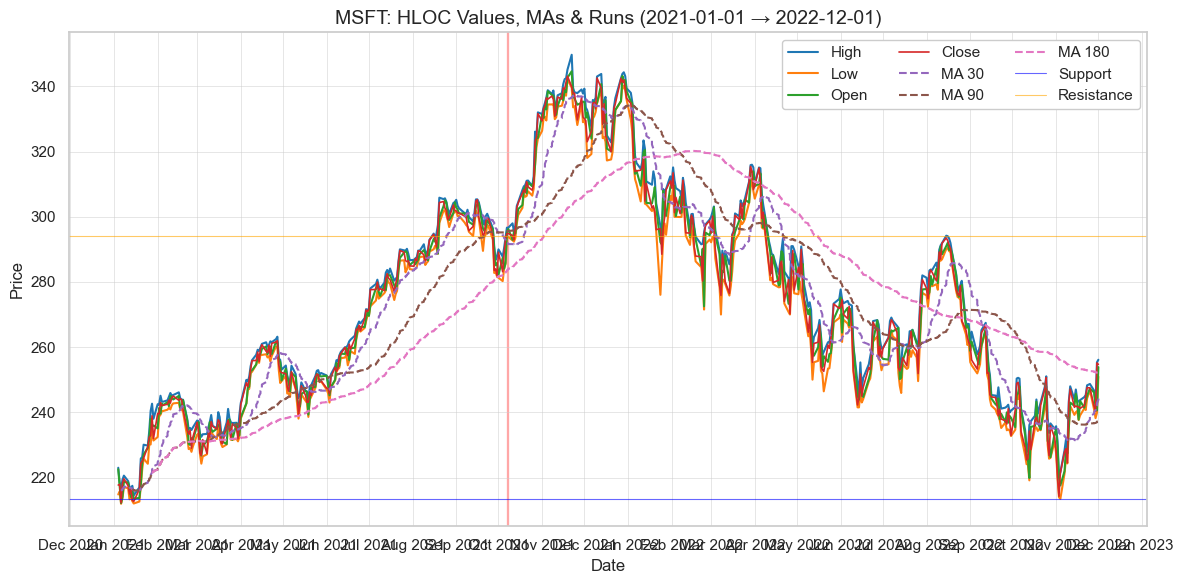

Completed chart for MSFT.

NVDA: detected 1 runs of 3+ days


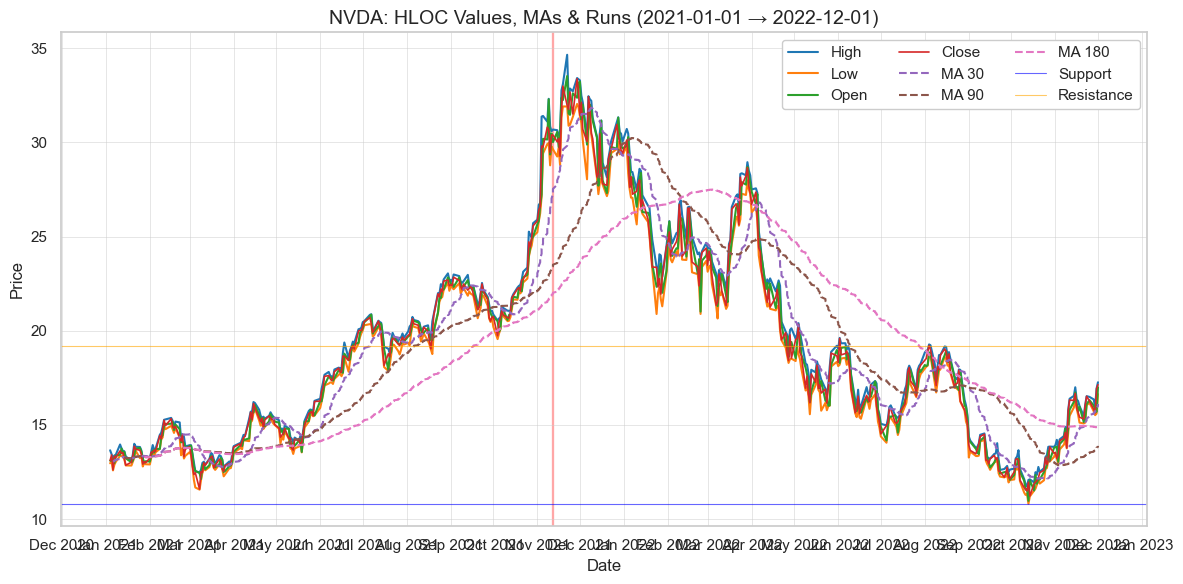

Completed chart for NVDA.

TSLA: detected 1 runs of 3+ days


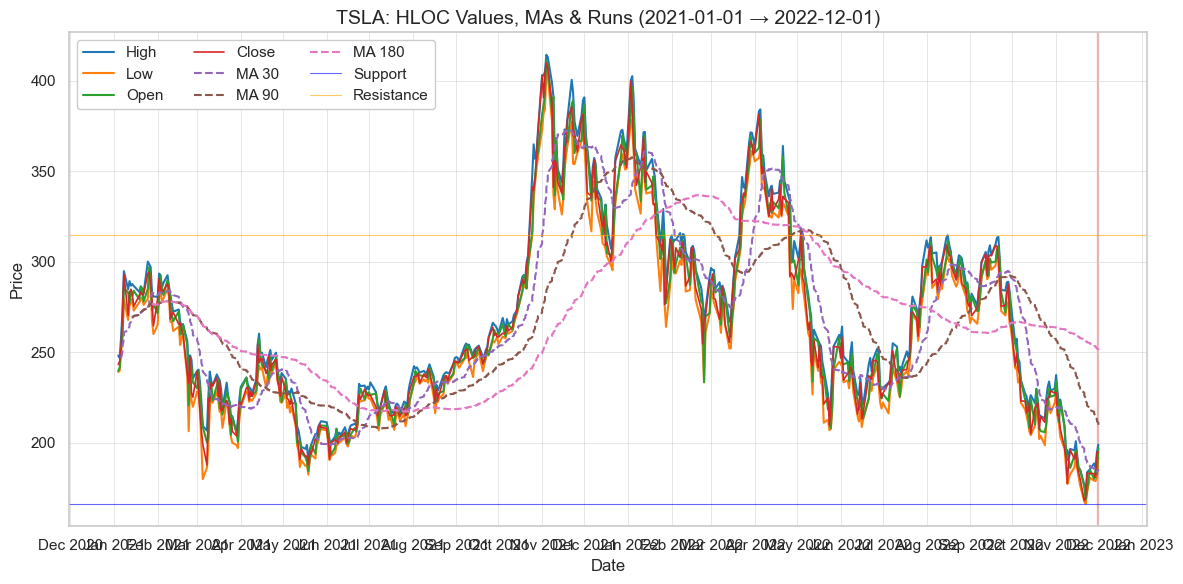

Completed chart for TSLA.



In [8]:
# User-defined timeframe and run settings (prompted once for all charts)
start_date_str = input("Enter start date for all charts (YYYY-MM-DD): ")
end_date_str = input("Enter end date for all charts (YYYY-MM-DD): ")
min_run_length = int(input("Enter minimum number of consecutive days for a run to be highlighted: "))

# Convert inputs to datetime
start_date = pd.to_datetime(start_date_str)
end_date = pd.to_datetime(end_date_str)

# Plot for every company
for name in companies:

    # Split company data from dataset
    df = dataset[dataset[COL_NAME] == name]
    df = df.sort_values(by=COL_DATE)

    # Filter dataset for the specified date range
    df = df[(df[COL_DATE] >= start_date) & (df[COL_DATE] <= end_date)]

    # Calculate and append Moving Averages
    for win in (30, 90, 180):  # 1, 3, 6 months
        df[f"MA_{win}"] = df[COL_CLOSE].rolling(window=win, min_periods=max(5, win // 5)).mean()

    # Calculate upward/downward runs based on diff. in closing prices
    df["Close_Diff"] = df[COL_CLOSE].diff()
    df["Run"] = df["Close_Diff"].apply(lambda x: 1 if x > 0 else (-1 if x < 0 else 0))
    df["Run_Group"] = (df["Run"] != df["Run"].shift()).cumsum()

    # Keep only runs meeting the minimum streak length
    run_segments = df.groupby("Run_Group").filter(lambda x: len(x) >= min_run_length)
    print(f"{name}: detected {run_segments['Run_Group'].nunique()} runs of {min_run_length}+ days")

    # Support/resistance window (fixed to show long-term range)
    sr_window = 60

    # Calculate support and resistance
    support = df[COL_LOW].rolling(window=sr_window, min_periods=1).min()
    resistance = df[COL_HIGH].rolling(window=sr_window, min_periods=1).max()

    # Use only one key recent support/resistance level (latest)
    support_levels = [support.tail(100).min()]
    resistance_levels = [resistance.tail(100).max()]

    # Plot and label values
    fig, ax = plt.subplots()
    ax.plot(df[COL_DATE], df[COL_HIGH], label="High", color='tab:blue')
    ax.plot(df[COL_DATE], df[COL_LOW], label="Low", color='tab:orange')
    ax.plot(df[COL_DATE], df[COL_OPEN], label="Open", color='tab:green')
    ax.plot(df[COL_DATE], df[COL_CLOSE], label="Close", color='tab:red', linewidth=1.2)

    # Plot and label Moving Averages
    ma_colors = {30: 'tab:purple', 90: 'tab:brown', 180: 'tab:pink'}
    for win in (30, 90, 180):
        ax.plot(df[COL_DATE], df[f"MA_{win}"], label=f"MA {win}", linestyle='--', color=ma_colors[win])

    # Plot support and resistance lines (thin continuous lines)
    for level in support_levels:
        ax.axhline(y=level, color='blue', linestyle='-', linewidth=0.8, alpha=0.6,
                   label="Support" if "Support" not in ax.get_legend_handles_labels()[1] else "")
    for level in resistance_levels:
        ax.axhline(y=level, color='orange', linestyle='-', linewidth=0.8, alpha=0.6,
                   label="Resistance" if "Resistance" not in ax.get_legend_handles_labels()[1] else "")

    # Highlight upward/downward runs (drawn behind other lines)
    for _, group in run_segments.groupby("Run_Group"):
        color = 'green' if group["Run"].iloc[0] == 1 else 'red'
        ax.axvspan(group[COL_DATE].iloc[0], group[COL_DATE].iloc[-1],
                   color=color, alpha=0.25, zorder=0)

    # Grid and x-axis formatting
    ax.grid(True, which='major', linestyle='-', linewidth=0.5, alpha=0.7)
    ax.grid(True, which='minor', linestyle='--', linewidth=0.3, alpha=0.4)

    ax.xaxis.set_major_locator(MonthLocator())
    ax.xaxis.set_major_formatter(DateFormatter('%b %Y'))

    # Label graph and axis
    ax.set_title(f"{name}: HLOC Values, MAs & Runs ({start_date_str} → {end_date_str})")
    ax.set_xlabel("Date")
    ax.set_ylabel("Price")
    ax.legend(ncol=3)
    plt.tight_layout()
    plt.show()

    print(f"Completed chart for {name}.\n")


In [93]:
from pathlib import Path


with open(Path.cwd().parent / "graphs" /  "figures" / "AAPL", "rb") as f:
    fig = pickle.load(f)

fig.axes[0].lines

<Axes.ArtistList of 10 lines>

In [53]:
fig.axes[0].lines

<Axes.ArtistList of 10 lines>